In [111]:
import  pandas as pd 
import numpy as np 
import  glob 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [112]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [113]:
files = glob.glob('*.csv')

files

['Youtube01.csv',
 'Youtube02.csv',
 'Youtube03.csv',
 'Youtube04.csv',
 'Youtube05.csv']

In [114]:
all_df=[]
for i in files:
    all_df.append(pd.read_csv(i).drop(['COMMENT_ID', 'DATE', 'AUTHOR'], axis=1))

In [115]:
all_df[0].head()

,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,"Hey, check out my new website!! This site is a...",1


In [116]:
df= pd.concat(all_df, ignore_index=True ,axis=0)
df

,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,"Hey, check out my new website!! This site is a...",1
...,...,...
1950,I love this song because we sing it at Camp al...,0
1951,I love this song for two reasons: 1.it is abou...,0
1952,wow,0
1953,Shakira u are so wiredo,0


In [117]:
print(f"Number of null values in each column:\n{df.isnull().sum()}")

Number of null values in each column:
CONTENT    0
CLASS      0
dtype: int64


In [118]:
 print(f"Number of duplicate rows:\n{df.duplicated().sum()}")

Number of duplicate rows:
196


In [119]:
df['CLASS'].value_counts()

CLASS
1    1004
0     951
Name: count, dtype: int64

<Axes: xlabel='CLASS', ylabel='count'>

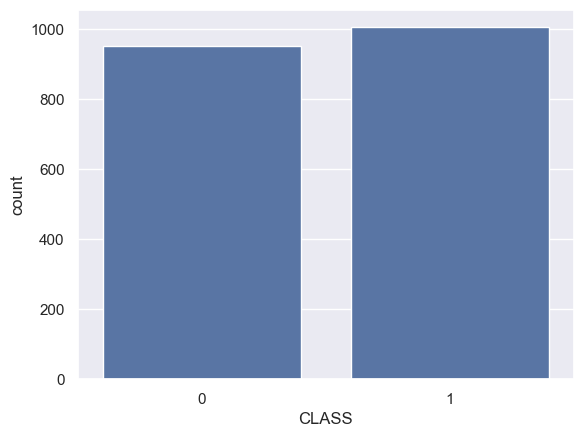

In [120]:
sns.countplot(x='CLASS', data=df)

In [121]:
message =['Hello World , in python ']
vector_sample=CountVectorizer()
vector_sample.fit(message)


,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [122]:
vector_sample.transform(['Hello World , in c++']).toarray()

array([[1, 1, 0, 1]], dtype=int64)

In [123]:
vector_sample.fit(message).get_feature_names_out()



array(['hello', 'in', 'python', 'world'], dtype=object)

In [124]:
x= df['CONTENT']
y= df['CLASS']

In [125]:
X_train , X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

In [126]:
Y_train.value_counts()

CLASS
1    803
0    761
Name: count, dtype: int64

In [127]:
Y_test.value_counts()

CLASS
1    201
0    190
Name: count, dtype: int64

In [128]:
vectorizer = CountVectorizer()

In [129]:
X_train_trans=vectorizer.fit_transform(X_train)
X_test_trans=vectorizer.transform(X_test)

In [130]:
X_train_trans.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [131]:
X_train_trans.shape

(1564, 3905)

In [132]:
X_test_trans.shape

(391, 3905)

In [133]:
clf= MultinomialNB()
clf.fit(X_train_trans, Y_train)



,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [135]:
clf.get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}

In [136]:
Y_pred= clf.predict(X_test_trans)

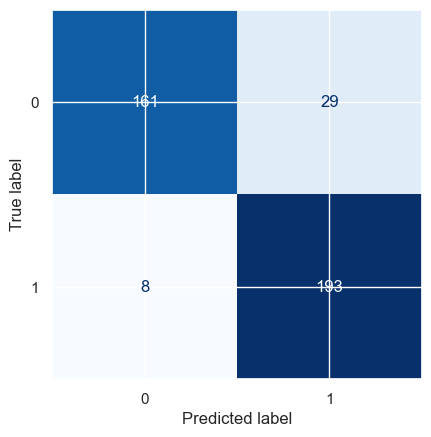

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, cmap='Blues', colorbar=False)


In [138]:
print(classification_report(Y_test, Y_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.95      0.85      0.90       190
        Spam       0.87      0.96      0.91       201

    accuracy                           0.91       391
   macro avg       0.91      0.90      0.90       391
weighted avg       0.91      0.91      0.90       391



In [139]:
messages = [
    "I am a spammer, please click on this link to win a free iPhone!",
    "Click here to claim your prize!",
    "You have won a lottery, please send your bank details to claim your prize!",
    "I love this website, it is very informative and helpful."
]

our_data = vectorizer.transform(messages)

predictions = clf.predict(our_data)

print(predictions)

[1 1 1 0]
